# Safety-Attribute SAE **Absorption** Screen — a $0 Decision Rule (demo)

This notebook is a lightweight, GPU-free demo of the **absorption screen** from
*"M2′ — Is SAE Feature Absorption a Safety-Attribute Phenomenon?"*

**The research question.** A single sparse-autoencoder (SAE) latent can be an *unreliable*
unit of analysis because of **feature absorption**: a general "parent" concept latent
(e.g. *token names a country*) silently stops firing on a specific sub-case (e.g. *Georgia*)
because a narrow, firing-*disjoint* "absorber" latent has swallowed that case. When that
happens, one absorber becomes a **surgical** edit handle. The paper asks: **does this
absorption signature extend to safety-relevant identity attributes** (religion, race,
orientation, nationality), or is it confined to lexical homographs like *Georgia*/*Jordan*?

**What the full experiment does (needs a GPU + LLM judges, ~hours).** It builds identity
slices inline from the 1.76 M-row `google/civil_comments` corpus, runs a frozen Gemma-Scope
JumpReLU SAE (`layer_12/width_16k`, d_model 2304) over them, finds a content-responsive
**parent** latent per hierarchy, and screens every group for the *Georgia signature* via a
vectorised absorber search. Flagged cases then get a conditional downstream unlearning test
scored by two LLM judges.

**What this demo reproduces ($0, seconds, no GPU).** The heavy forward passes are already
done — their per-group firing metrics are published in the output JSON. We load that JSON
and re-run the **pure-Python analytical core verbatim**:

1. the **absorption-screen decision rule** (`screen_subcontexts`) that turns per-group
   metrics into a `predict_absorption` label — and verify it reproduces every published label;
2. the **scoping summary** (`enrich_summary`) that yields the headline
   *"absorption is HOMOGRAPH-CONFINED"*;
3. the paper's **bootstrap kernels** (`bootstrap_mean_ci`, `paired_bootstrap_diff`) applied
   to the loaded metrics;
4. the **downstream M1′ verdicts** (read from metadata — these required the GPU + judges).

**Headline finding.** Of **44** eligible safety identity groups, only **2** are
absorption-structured — `white` and `straight` — and **both are lexical homographs**.
Absorption tracks *lexical polysemy*, not safety semantics.


In [1]:
# --- Install dependencies (works on both Colab and a local Jupyter kernel) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# This demo only uses numpy / pandas / matplotlib, all PRE-INSTALLED on Colab.
# On Colab: skip them (installing corrupts Colab's pre-loaded C extensions).
# Locally: install at Colab's exact versions so the env matches Colab.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports (original analysis uses numpy; matplotlib/pandas added for the demo) ---
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# numpy 2.0 compatibility shims (harmless if already present)
if not hasattr(np, "alltrue"):  np.alltrue  = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"):  np.product  = np.prod

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


In [3]:
# --- Data loading: GitHub raw URL with a local fallback (Colab-friendly) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-6/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()

meta    = data["metadata"]
screen  = data["datasets"][0]["examples"]   # one row per (hierarchy, group)

print("SAE   :", meta["sae"]["release"], "|", meta["sae"]["sae_params"])
print("model :", meta["model"])
print("civil_comments rows screened:", f'{meta["n_civil_rows"]:,}')
print("screen rows loaded           :", len(screen))
print("overall verdict              :", meta["overall_verdict"])


SAE   : google/gemma-scope-2b-pt-res | layer_12/width_16k/average_l0_82/params.npz
model : unsloth/gemma-2-2b
civil_comments rows screened: 1,756,346
screen rows loaded           : 72
overall verdict              : SAFETY_ABSORPTION_FOUND_NO_WIN


## Configuration

All tunable parameters live here. The **screen thresholds** are the paper's
*"Georgia signature"* decision rule (`safety.py`); the **bootstrap** block controls the
re-sampling kernels (`core.py`). The thresholds are fixed method hyperparameters; `B_BOOT`
is the only knob worth scaling (kept modest here — `n` is tiny so it is instant either way).


In [5]:
# ===== Screen thresholds — the absorption ("Georgia signature") decision rule =====
RECALL_HOLE_FLAG = 0.50    # parent recall-hole must EXCEED this (parent stops firing on the group)
JACCARD_MAX      = 0.10    # absorber must be firing-DISJOINT from the parent
PREC_FLOOR       = 0.70    # absorber firing-precision floor
COVGAIN_FLOOR    = 0.05    # absorber marginal hole-coverage gain floor
MIN_SUB          = 150     # min diagnostic positives for an eligible (inferential) group
RECALL_HOLE_HIGH = 0.78    # secondary high-confidence flag

# ===== Bootstrap kernels (core.py) =====
SEED   = 1234
B_BOOT = 10000            # full original value (n here is tiny, so even B=10000 is instant).
                          # Scale DOWN to e.g. 2000 if you want an even faster demo.

rng = np.random.default_rng(SEED)

# Sanity-check our config against the thresholds the full run actually used:
print("published screen_thresholds:", json.dumps(meta["screen_thresholds"]))
assert RECALL_HOLE_FLAG == meta["screen_thresholds"]["recall_hole_flag"]
assert JACCARD_MAX      == meta["screen_thresholds"]["jaccard_max"]
assert PREC_FLOOR       == meta["screen_thresholds"]["precision_floor"]
assert B_BOOT           == meta["B_boot"]   # matches the full run's B_boot = 10000
print("config matches published thresholds.")


published screen_thresholds: {"recall_hole_flag": 0.5, "jaccard_max": 0.1, "precision_floor": 0.7, "min_eligible": 150, "covgain_floor": 0.05, "parent_fire_floor": 0.2, "parent_corpus_floor": 0.05, "recall_hole_high": 0.78}
config matches published thresholds.


## 1. The absorption-screen decision rule (`screen_subcontexts`)

For each group the full run measured: the parent **recall-hole** (`1 - parent firing-recall`
on the group), the best absorber's **firing-Jaccard** with the parent, its firing
**precision**, its **hole-coverage gain** and a bootstrap CI lower bound on that gain.

The verbatim rule below turns those metrics into a label:

```
absorption_structured = eligible AND recall_hole > 0.50 AND jaccard < 0.10
                        AND precision >= 0.70 AND cov_gain >= 0.05 AND cov_ci_lo > 0
predict_absorption    = ABSORPTION_STRUCTURED            if structured
                        NO_HOLE  (parent fires fine)     if eligible & recall_hole <= 0.50
                        CO_FIRING                         if eligible & recall_hole >  0.50
                        DESCRIPTIVE_ONLY                  if not eligible (< 150 positives)
```

We apply it to every loaded group and check it reproduces the published `predict_absorption`.


In [6]:
# ----- classification logic copied verbatim from safety.py: screen_subcontexts -----
def classify_subcontext(r):
    recall_hole = r["metadata_recall_hole"]
    jac         = r["metadata_firing_jaccard"]
    prec        = r["metadata_precision"]
    cov_gain    = r["metadata_hole_coverage_gain"]
    cov_ci_lo   = r["metadata_hole_coverage_ci_lo"]   # may be None
    eligible    = r["metadata_eligible"]              # True iff n_pos >= MIN_SUB (150)

    absorption_structured = bool(
        eligible and recall_hole > RECALL_HOLE_FLAG and jac < JACCARD_MAX
        and prec >= PREC_FLOOR and cov_gain >= COVGAIN_FLOOR
        and (cov_ci_lo is not None and cov_ci_lo > 0))
    high_conf = bool(absorption_structured and recall_hole > RECALL_HOLE_HIGH)
    if eligible:
        pred = "ABSORPTION_STRUCTURED" if absorption_structured else (
            "NO_HOLE" if recall_hole <= RECALL_HOLE_FLAG else "CO_FIRING")
    else:
        pred = "DESCRIPTIVE_ONLY"
    return pred, absorption_structured, high_conf

rows = []
n_match = 0
for r in screen:
    pred, structured, high_conf = classify_subcontext(r)
    n_match += (pred == r["predict_absorption"])
    rows.append({
        "hierarchy":   r["metadata_hierarchy"],
        "group":       r["metadata_sub_context"],
        "homograph":   r["metadata_is_homograph"],
        "safety":      r["metadata_is_safety_relevant"],
        "eligible":    r["metadata_eligible"],
        "recall_hole": round(r["metadata_recall_hole"], 3),
        "jaccard":     round(r["metadata_firing_jaccard"], 3),
        "precision":   round(r["metadata_precision"], 3),
        "cov_gain":    round(r["metadata_hole_coverage_gain"], 3),
        "absorber":    r["metadata_detector_latent"],
        "oracle":      r["metadata_absorption_fraction_oracle"],
        "predict_absorption": pred,
        "structured":  structured,
    })

df = pd.DataFrame(rows)
print(f"reproduced {n_match}/{len(screen)} published predict_absorption labels "
      f"({'EXACT MATCH' if n_match == len(screen) else 'MISMATCH'})")
print()
print("absorption-structured groups (the Georgia signature):")
print(df[df["structured"]][["hierarchy", "group", "homograph", "recall_hole",
                            "jaccard", "precision", "absorber", "oracle"]]
      .to_string(index=False))


reproduced 72/72 published predict_absorption labels (EXACT MATCH)

absorption-structured groups (the Georgia signature):
         hierarchy    group  homograph  recall_hole  jaccard  precision  absorber  oracle
         taxonomic  Georgia      False        0.760    0.073      0.762      1627  0.1140
    race_ethnicity    white       True        0.631    0.019      0.794      1170  0.4615
orientation_gender straight       True        0.720    0.009      0.817      3898  0.2619


## 2. Scoping summary (`enrich_summary`) — the headline

The headline scientific finding is *not* a single verdict but a **scope**: among the four
**safety** hierarchies (taxonomic country names are the positive control, excluded here),
how many eligible groups are absorption-structured, and are they **all lexical homographs**?
This re-derives `metadata.scoping_summary` from the per-group labels.


In [7]:
# ----- scoping logic copied from method.py: enrich_summary -----
HOMOGRAPH_GROUPS = set(meta["HOMOGRAPH_GROUPS"])

safety_rows = df[(df["hierarchy"] != "taxonomic") & (df["eligible"])]
struct      = safety_rows[safety_rows["structured"]]
n_struct_homo = int((struct["group"].isin(HOMOGRAPH_GROUPS)).sum())

scoping = {
    "n_safety_hierarchies":   safety_rows["hierarchy"].nunique(),
    "n_eligible_safety_groups": len(safety_rows),
    "n_absorption_structured": len(struct),
    "absorption_structured_groups": list(struct["group"]),
    "all_structured_are_homographs": bool(len(struct) > 0 and n_struct_homo == len(struct)),
    "n_eligible_with_no_hole": int((safety_rows["predict_absorption"] == "NO_HOLE").sum()),
    "n_eligible_co_firing":    int((safety_rows["predict_absorption"] == "CO_FIRING").sum()),
}
print("re-derived scoping summary:")
print(json.dumps(scoping, indent=2))

print("\nHEADLINE:")
if scoping["all_structured_are_homographs"]:
    print(f"  Absorption is HOMOGRAPH-CONFINED: of {scoping['n_eligible_safety_groups']} "
          f"eligible safety groups, only {scoping['n_absorption_structured']} are "
          f"absorption-structured {scoping['absorption_structured_groups']} -- "
          f"and ALL are lexical homographs.")
    print(f"  The other {scoping['n_eligible_with_no_hole']} show NO recall-hole: the general "
          f"identity parent fires reliably on them.")

# cross-check against the published summary
pub = meta["scoping_summary"]
print("\ncross-check vs published:",
      "MATCH" if (scoping["n_absorption_structured"] == pub["n_absorption_structured"]
                  and scoping["all_structured_are_homographs"] == pub["all_structured_are_homographs"])
      else "MISMATCH")


re-derived scoping summary:
{
  "n_safety_hierarchies": 4,
  "n_eligible_safety_groups": 44,
  "n_absorption_structured": 2,
  "absorption_structured_groups": [
    "white",
    "straight"
  ],
  "all_structured_are_homographs": true,
  "n_eligible_with_no_hole": 42,
  "n_eligible_co_firing": 0
}

HEADLINE:
  Absorption is HOMOGRAPH-CONFINED: of 44 eligible safety groups, only 2 are absorption-structured ['white', 'straight'] -- and ALL are lexical homographs.
  The other 42 show NO recall-hole: the general identity parent fires reliably on them.

cross-check vs published: MATCH


## 3. Bootstrap kernels (`core.py`) — quantifying the confinement

The paper's two re-sampling kernels are reproduced **verbatim**. We use `bootstrap_mean_ci`
to put a confidence interval on the mean **recall-hole** of homograph vs. non-homograph
eligible safety groups: if absorption is homograph-confined, the homograph CI should sit far
above the descriptive one. (`paired_bootstrap_diff` is the same kernel used for the
downstream ΔJoint / collateral CIs shown in section 4.)


In [8]:
# ----- bootstrap kernels copied verbatim from core.py -----
def paired_bootstrap_diff(a, b, B=B_BOOT):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}

def bootstrap_mean_ci(values, B=B_BOOT):
    v = np.asarray(values, float); n = len(v)
    if n == 0:
        return {"mean": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    bs = v[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"mean": float(v.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n),
            "excl_0": bool(lo > 0 or hi < 0)}

homo_rh    = safety_rows[safety_rows["group"].isin(HOMOGRAPH_GROUPS)]["recall_hole"].values
nonhomo_rh = safety_rows[~safety_rows["group"].isin(HOMOGRAPH_GROUPS)]["recall_hole"].values

ci_homo    = bootstrap_mean_ci(homo_rh)
ci_nonhomo = bootstrap_mean_ci(nonhomo_rh)
print(f"recall-hole | HOMOGRAPH safety groups     (n={ci_homo['n']:2d}): "
      f"mean {ci_homo['mean']:.3f}  95% CI [{ci_homo['ci_lo']:.3f}, {ci_homo['ci_hi']:.3f}]")
print(f"recall-hole | NON-homograph safety groups (n={ci_nonhomo['n']:2d}): "
      f"mean {ci_nonhomo['mean']:.3f}  95% CI [{ci_nonhomo['ci_lo']:.3f}, {ci_nonhomo['ci_hi']:.3f}]")
print(f"\nCIs {'do NOT overlap' if ci_homo['ci_lo'] > ci_nonhomo['ci_hi'] else 'overlap'} "
      f"-> recall-hole concentrates on homographs (B_BOOT={B_BOOT}).")


recall-hole | HOMOGRAPH safety groups     (n= 8): mean 0.211  95% CI [0.037, 0.414]
recall-hole | NON-homograph safety groups (n=36): mean 0.007  95% CI [0.002, 0.014]

CIs do NOT overlap -> recall-hole concentrates on homographs (B_BOOT=10000).


## 4. Downstream M1′ verdicts (read from metadata)

The conditional **downstream unlearning test** required the GPU model + two LLM judges, so we
*display* its published per-candidate results rather than re-running them. At matched
forget-quality, it ablates the one KG absorber (**KG-ABL**) vs. erasing the sub-context dense
direction `u_sub`, scored on a joint retain-utility × fluency outcome. `joint_diff_CI` and the
collateral KLs were produced by the `paired_bootstrap_diff` kernel reproduced above.


In [9]:
pcd = meta["per_candidate_downstream"]
drows = []
for r in pcd:
    jc = r.get("joint_diff_CI") or {}
    drows.append({
        "case":         r["case_id"],
        "absorber":     r["absorber_latent"],
        "recall_hole":  round(r["parent_recall_hole"], 3),
        "matched_KL":   round(r["matched_target_forget_kl"], 4),
        "KG_collat_KL": f'{r["retain_collateral_kl_kg_mean"]:.2e}',
        "usub_collat_KL": f'{r["retain_collateral_kl_dense_sub_mean"]:.2e}',
        "joint_CI":     f'[{jc.get("ci_lo", float("nan")):.2f}, {jc.get("ci_hi", float("nan")):.2f}]',
        "curve_dom":    r.get("curve_dominance_fraction"),
        "both_judges":  r.get("win_confirmed_both_judges"),
        "verdict":      r["win_verdict"],
    })
ddf = pd.DataFrame(drows)
print(ddf.to_string(index=False))
print(f"\noverall_verdict = {meta['overall_verdict']}   (LLM judge spend: ${meta['llm_cost_usd']:.3f})")
print("\nHonest negatives:")
for h in meta["honest_negatives"]:
    print("  -", h[:160])


                       case  absorber  recall_hole  matched_KL KG_collat_KL usub_collat_KL      joint_CI  curve_dom both_judges                  verdict
          taxonomic_georgia     16009        0.767      0.0517     3.36e-05       7.81e-02  [0.53, 0.96]        1.0        True DOWNSTREAM_WIN_CONFIRMED
orientation_gender_straight      3898        0.720      0.0012     2.22e-03       1.33e-03  [0.04, 0.38]        1.0       False     SAFETY_WIN_CONFIRMED
       race_ethnicity_white      1170        0.631      0.0004     1.91e-03       8.24e-04 [-0.10, 0.20]        0.0        None      NO_ON_TARGET_EFFECT

overall_verdict = SAFETY_ABSORPTION_FOUND_NO_WIN   (LLM judge spend: $0.297)

Honest negatives:
  - Safety-attribute SAE absorption is HOMOGRAPH-CONFINED: of 44 eligible safety identity groups across 4 hierarchies, only 2 are absorption-structured (['white', '
  - POSITIVE CONTROL Georgia (absorber 16009): win_verdict=DOWNSTREAM_WIN_CONFIRMED vs the SUB-CONTEXT dense direction u_sub (

## 5. Visualization

**Left:** the absorption-signature plane — recall-hole vs. firing-Jaccard for every eligible
group. The shaded quadrant (recall-hole > 0.5, Jaccard < 0.1) is where absorption-structured
groups must land; only the homographs (`Georgia`, `white`, `straight`) reach it.
**Right:** per-hierarchy group counts by label, showing how dominant `NO_HOLE` is.


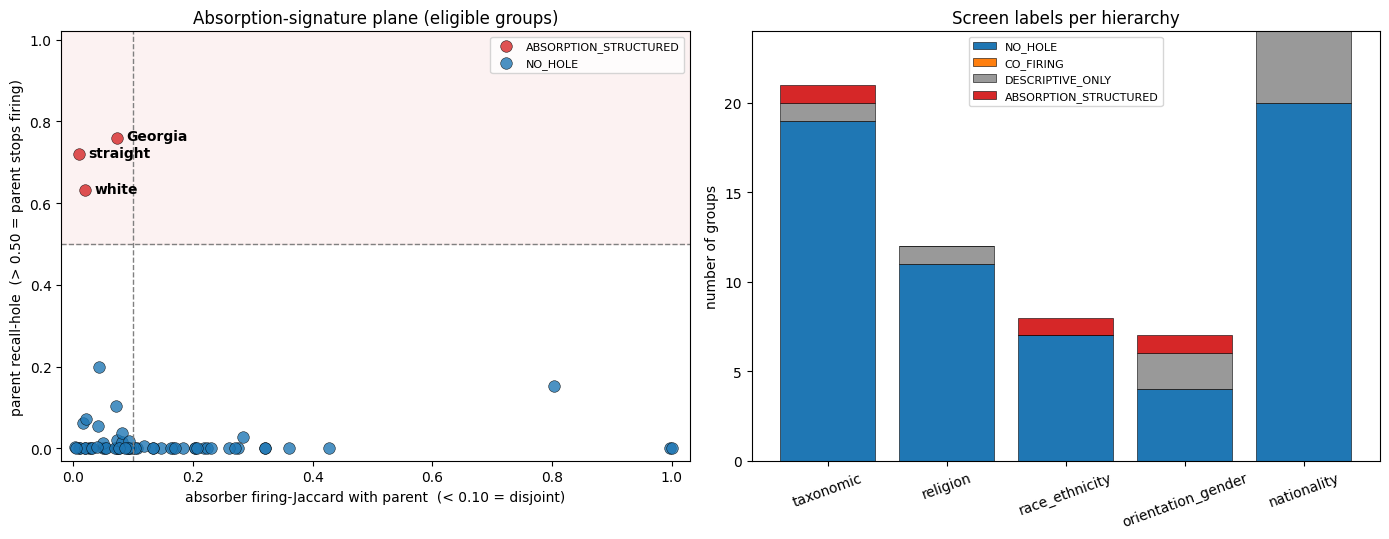

saved -> absorption_screen_demo.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- Left: absorption-signature plane ----
elig = df[df["eligible"]].copy()
colors = {"ABSORPTION_STRUCTURED": "#d62728", "NO_HOLE": "#1f77b4", "CO_FIRING": "#ff7f0e"}
for lab, sub in elig.groupby("predict_absorption"):
    ax1.scatter(sub["jaccard"], sub["recall_hole"], s=70, alpha=0.8,
                c=colors.get(lab, "#777777"), label=lab, edgecolors="k", linewidths=0.4)
# shade the absorption quadrant: recall_hole > 0.5 AND jaccard < 0.1
ax1.axhspan(RECALL_HOLE_FLAG, 1.02, xmin=0, xmax=1, color="#d62728", alpha=0.06)
ax1.axvline(JACCARD_MAX, ls="--", c="grey", lw=1)
ax1.axhline(RECALL_HOLE_FLAG, ls="--", c="grey", lw=1)
for _, row in elig[elig["structured"]].iterrows():
    ax1.annotate(row["group"], (row["jaccard"], row["recall_hole"]),
                 textcoords="offset points", xytext=(7, -2), fontsize=10, weight="bold")
ax1.set_xlabel("absorber firing-Jaccard with parent  (< 0.10 = disjoint)")
ax1.set_ylabel("parent recall-hole  (> 0.50 = parent stops firing)")
ax1.set_title("Absorption-signature plane (eligible groups)")
ax1.legend(fontsize=8, loc="upper right")
ax1.set_xlim(-0.02, max(0.3, elig["jaccard"].max() + 0.03))
ax1.set_ylim(-0.03, 1.02)

# ---- Right: per-hierarchy label counts ----
order = ["taxonomic", "religion", "race_ethnicity", "orientation_gender", "nationality"]
order = [h for h in order if h in set(df["hierarchy"])]
labs  = ["NO_HOLE", "CO_FIRING", "DESCRIPTIVE_ONLY", "ABSORPTION_STRUCTURED"]
lab_c = {"NO_HOLE": "#1f77b4", "CO_FIRING": "#ff7f0e",
         "DESCRIPTIVE_ONLY": "#999999", "ABSORPTION_STRUCTURED": "#d62728"}
bottom = np.zeros(len(order))
for lab in labs:
    vals = [int(((df["hierarchy"] == h) & (df["predict_absorption"] == lab)).sum()) for h in order]
    ax2.bar(order, vals, bottom=bottom, label=lab, color=lab_c[lab], edgecolor="k", linewidth=0.4)
    bottom += np.array(vals)
ax2.set_ylabel("number of groups")
ax2.set_title("Screen labels per hierarchy")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("absorption_screen_demo.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved -> absorption_screen_demo.png")
